## * Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

## * The Dataset and its Dimensions

In [2]:
df=pd.read_csv("telecom_dataset.csv")

In [3]:
df.shape

(7043, 21)

## *Type of data 

In [4]:
type(df)

pandas.core.frame.DataFrame

## *Summary of Dataset's fundamental attribute's

In [5]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [9]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# -> Data Cleaning

## *Checking for Duplicates

In [10]:
df.duplicated().sum()

0

## *Checking for null values

In [11]:
df.replace({" ":np.nan},inplace=True)

In [12]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [13]:
df_raw=df.copy()

## *Droping the attribute that is not useful

In [14]:
df=df.drop(columns=["customerID"],errors="ignore")

## *Converting selected attribute's into binary numerical values

In [15]:
df["gender"]=(df["gender"].map({'Female':1,'Male':0}))

In [16]:
df['SeniorCitizen'].value_counts()

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

In [17]:
df['SeniorCitizen']=df['SeniorCitizen'].astype(str)
df['SeniorCitizen'].value_counts()

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

In [18]:
df['gender']=df['gender'].astype(str)

## *Converting TotalCharges to numeric dtype

In [19]:
df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges']*df['tenure'])
print(df["TotalCharges"])
df['TotalCharges'].dtype

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64


dtype('float64')

### *Checking for null values after handling nullvalues

In [20]:
print(df['TotalCharges'].isnull().sum())

0


## *Checking for Outlier's

In [21]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in numeric_cols:
    Q1,Q3 = df[col].quantile([0.25,0.75])
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {outlier_count} outliers")


tenure: 0 outliers
MonthlyCharges: 0 outliers
TotalCharges: 0 outliers


In [22]:
z_scores = np.abs(stats.zscore(df[['MonthlyCharges', 'TotalCharges']].dropna()))
outliers = (z_scores > 3).sum() 
print(outliers)

MonthlyCharges    0
TotalCharges      0
dtype: int64


## Distribution of each numeric feature

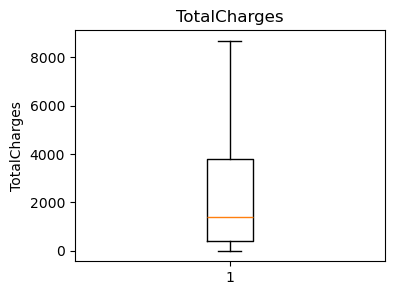

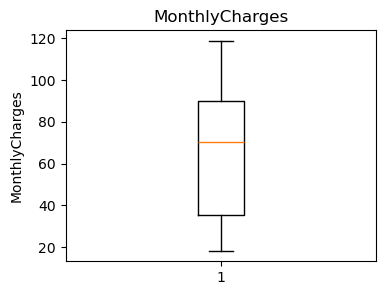

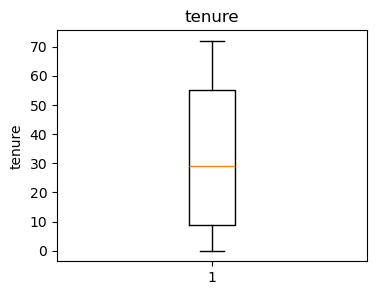

In [23]:

cols=['TotalCharges','MonthlyCharges','tenure']
for col in cols:
    plt.figure(figsize=(4,3))
    plt.boxplot(df[col].dropna())
    plt.title(col)
    plt.ylabel(col)
    plt.show()

It tells the median, spread, and outliers.
tenure: Many customers with short tenure.
MonthlyCharges: Moderate spread, fewer outliers.
TotalCharges: Skewd with several outliers.

## *Datatypes after converting the dtypes of selected attributes

In [24]:
df.dtypes.value_counts()

object     17
float64     2
int64       1
Name: count, dtype: int64

## *Target Attribute

In [25]:
churn_count=df['Churn'].value_counts()
churn_count

Churn
No     5174
Yes    1869
Name: count, dtype: int64

plt.figure(figsize=(4,3))
plt.bar(churn_count.index, churn_count.values)
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.title('Churn Distribution')
plt.show()

Absolute number of churned v.v non-churned customers Non Churn customers are significantly more than churned ones.

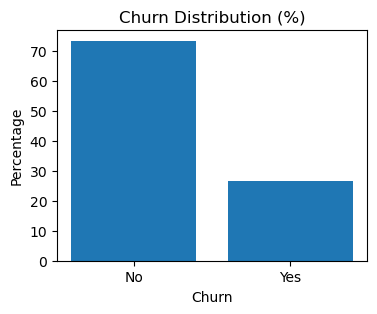

In [26]:
churn_pct = df['Churn'].value_counts(normalize=True) * 100
plt.figure(figsize=(4,3))
plt.bar(churn_pct.index, churn_pct.values)
plt.ylabel('Percentage')
plt.xlabel('Churn')
plt.title('Churn Distribution (%)')
plt.show()


 Proportion (%) of churn vs non-churn. Around ~26–27% customers churned ~73–74% retained

##  *Dimensions after having some changes in the dataset

In [27]:
df.shape

(7043, 20)

## *Univariate Analysis(Numerical):

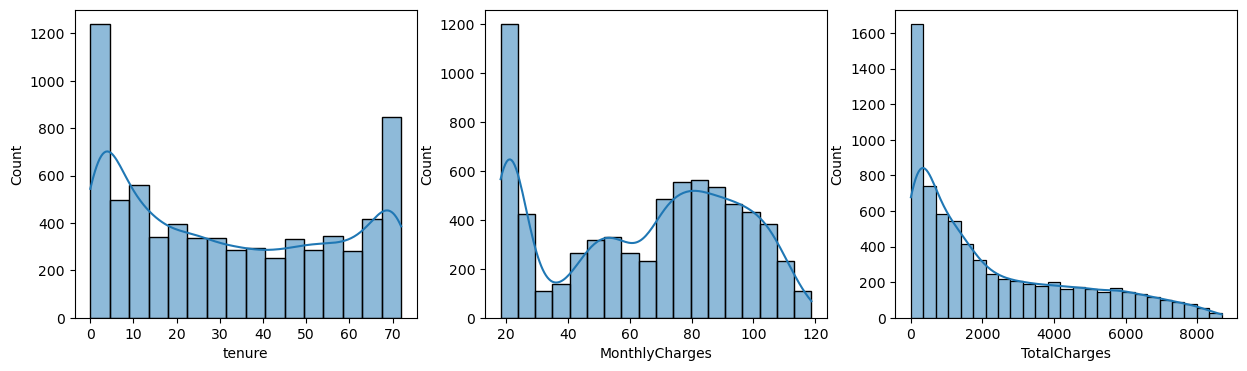

In [28]:
fig,axes=plt.subplots(1,3,figsize=(15,4))
plt.subplots_adjust(hspace=0.6) 
df_num=df[['tenure','MonthlyCharges','TotalCharges']]
for i,col in enumerate(df_num):
    sns.histplot(df[col],kde=True,ax=axes[i])
plt.show()

Distribution shape of numeric variables
tenure: Skewed towards lower values
MonthlyCharges: Nearly normal but slightly right-skewed
TotalCharges: Highly right-skewed

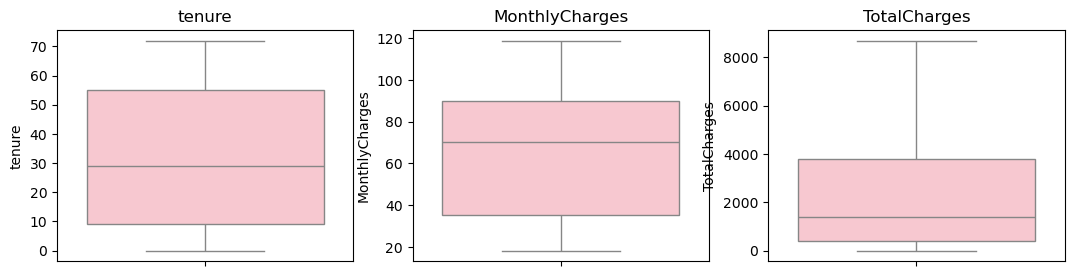

In [29]:
fig,axes=plt.subplots(1,3,figsize=(13,3))
plt.subplots_adjust(hspace=0.6) 
df_num=df[['tenure','MonthlyCharges','TotalCharges']]
for i,col in enumerate(df_num):
    sns.boxplot(data=df[col],ax=axes[i],color='pink')
    axes[i].set_title(col)
plt.show()

Outliers and spread visually.
Confirms earlier IQR-based outlier detection.
TotalCharges has the most extreme values

## *Univariate Analysis(Categorical):

Frequency distribution of categorical variables

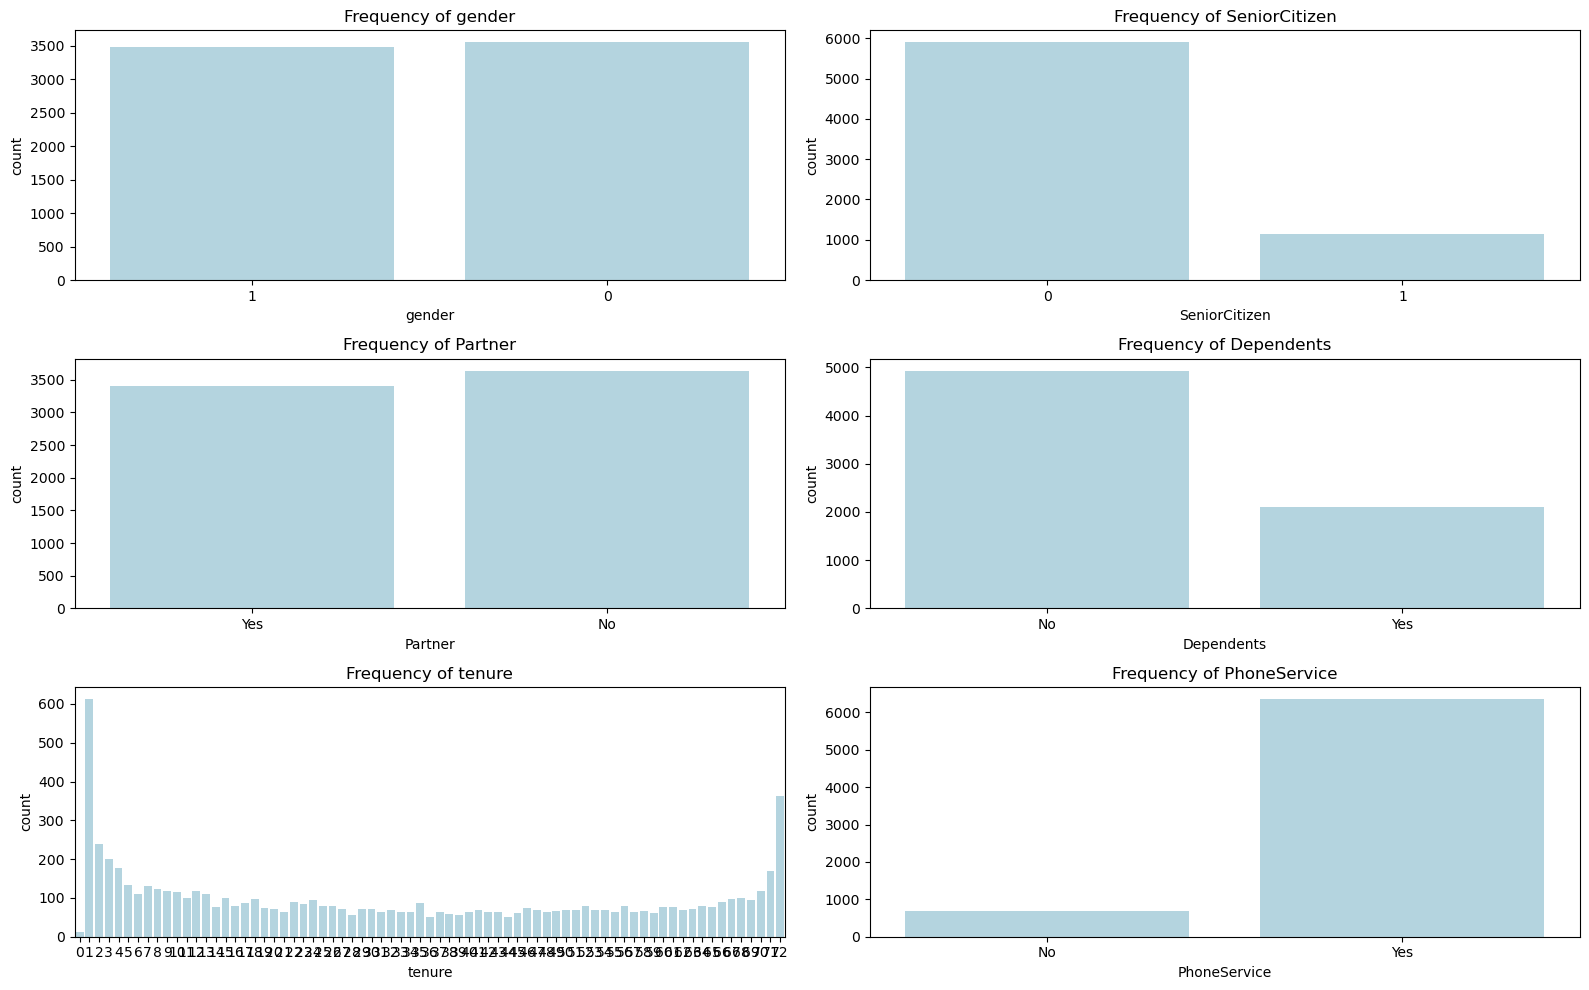

In [30]:
fig, axes = plt.subplots(3,2, figsize=(16,10))
axes = axes.flatten()
plt.subplots_adjust(hspace=0.6)
cols = ['gender','SeniorCitizen','Partner','Dependents','tenure','PhoneService']
for i, col in enumerate(cols):
        sns.countplot( x=col,data=df,ax=axes[i],color='lightblue')
        axes[i].set_title(f"Frequency of {col}")
plt.tight_layout()
plt.show()


Majority are non-senior citizens.
Most customers have phone service.
Partner and dependents are fairly balanced.

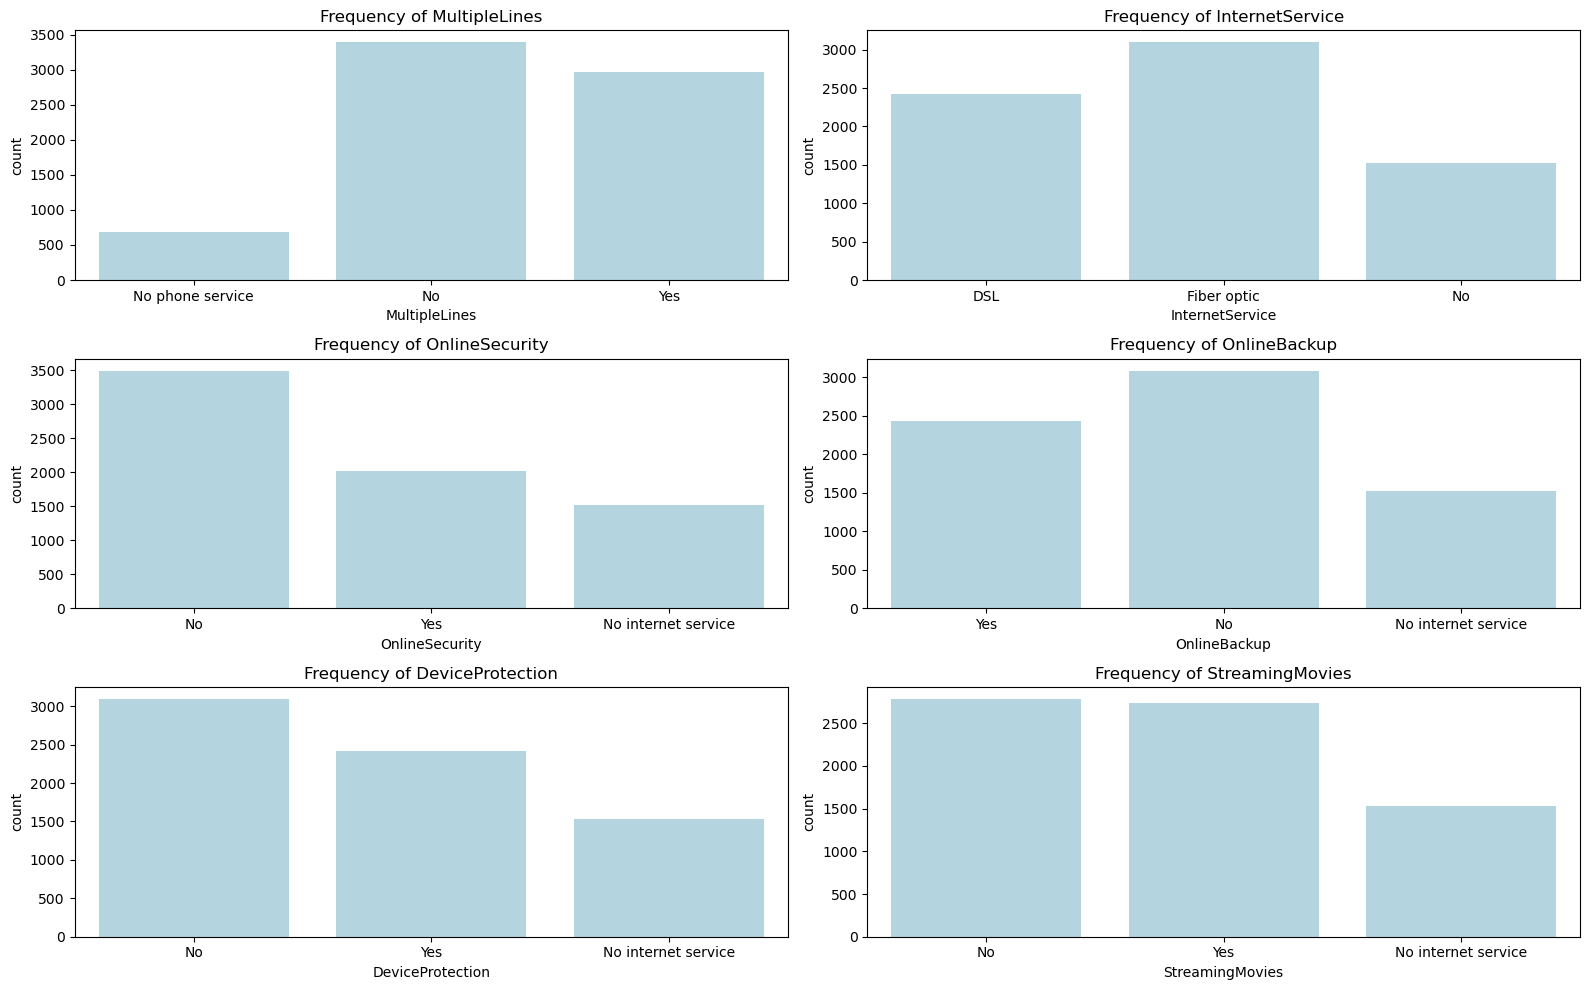

In [31]:
fig, axes = plt.subplots(3,2, figsize=(16,10))
axes = axes.flatten()
plt.subplots_adjust(hspace=0.6)
cols=['MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','StreamingMovies']
for i, col in enumerate(cols):
        sns.countplot( x=col,data=df,ax=axes[i],color='lightblue')
        axes[i].set_title(f"Frequency of {col}")
plt.tight_layout()
plt.show()

Many customers lack add-on services like OnlineSecurity.
Fiber optic customers are prominent

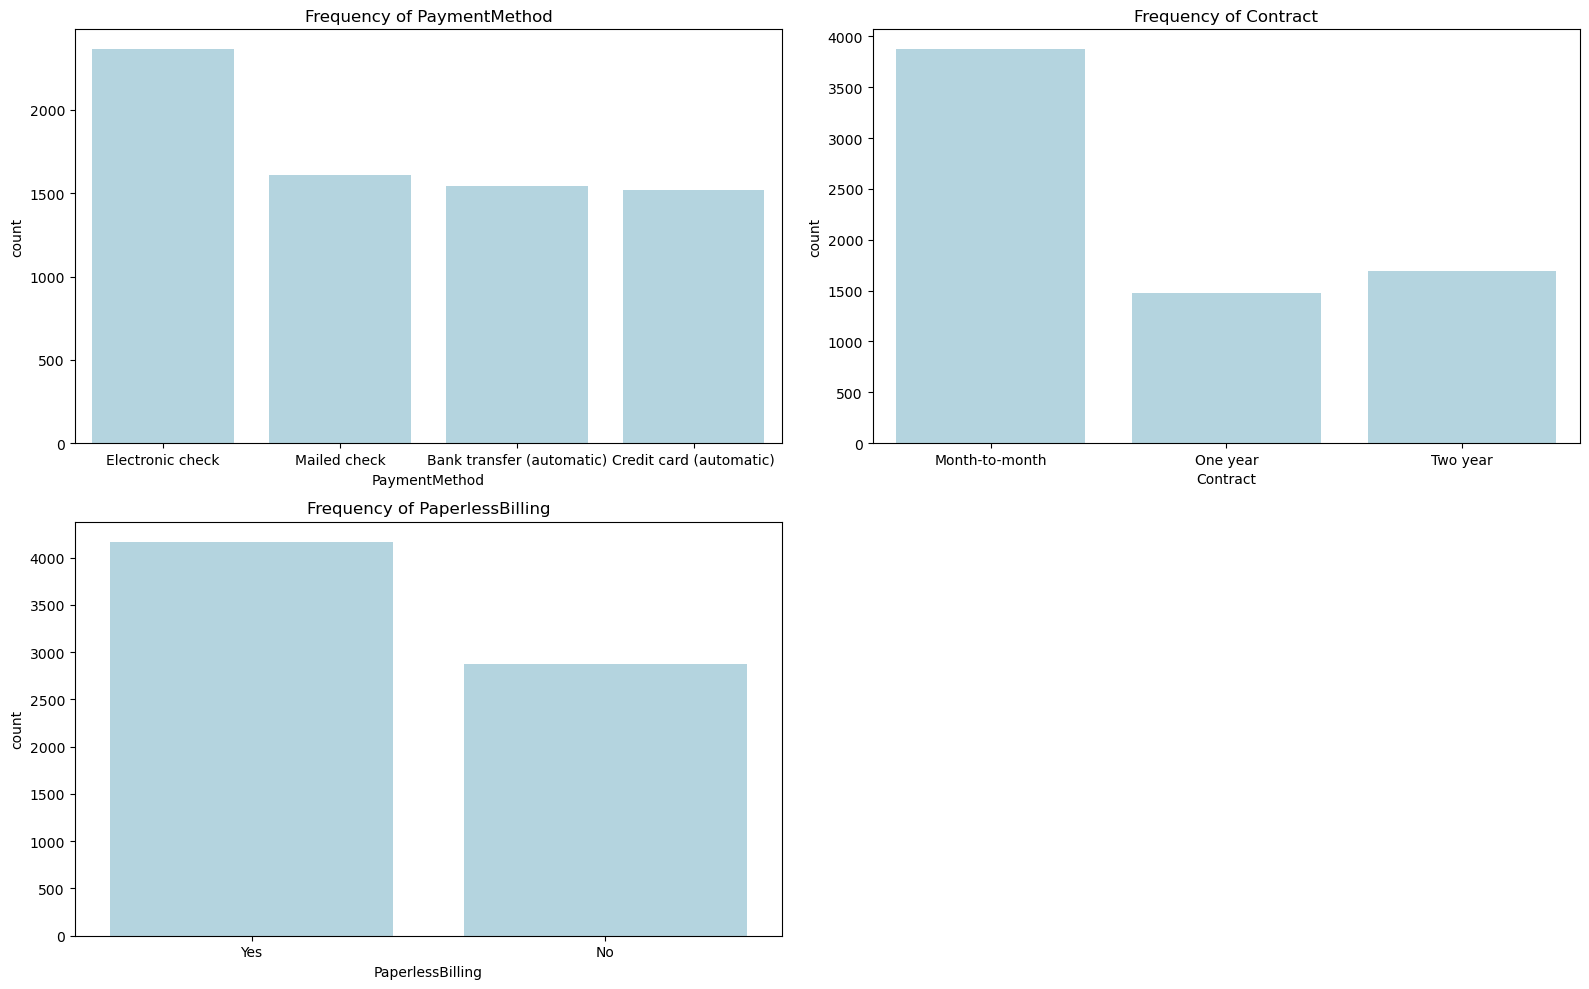

In [32]:
fig, axes = plt.subplots(2,2, figsize=(16,10))
axes = axes.flatten()
plt.subplots_adjust(hspace=0.6)
cols=['PaymentMethod','Contract','PaperlessBilling']
for i, col in enumerate(cols):
        sns.countplot( x=col,data=df,ax=axes[i],color='lightblue')
        axes[i].set_title(f"Frequency of {col}")
fig.delaxes(axes[len(cols)])
plt.tight_layout()
plt.show()

Month-to-month contracts dominate.
Paperless billing is common

# *Bivariate Analysis(Numerical):

Comparison of numeric features across churn categories

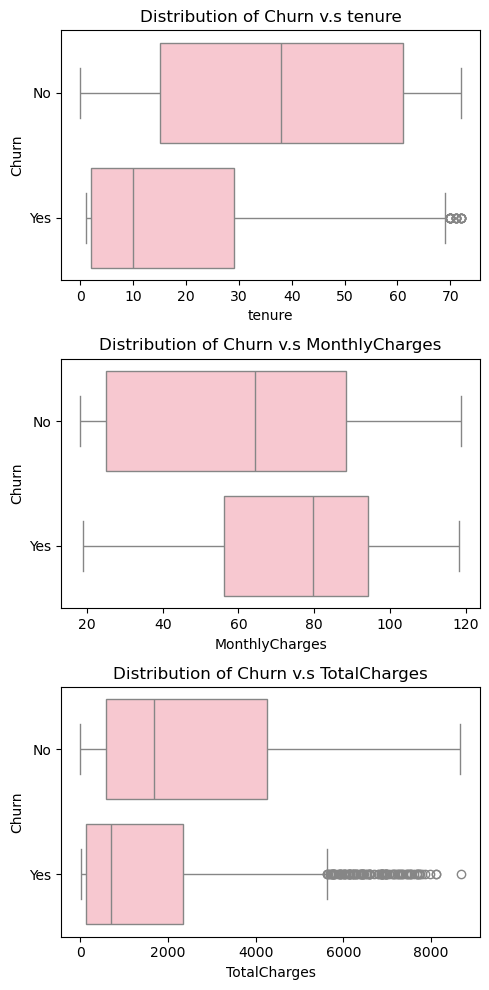

In [33]:
fig,axes=plt.subplots(3,1,figsize=(5,10))
axes=axes.flatten()
plt.subplots_adjust(hspace=0.6)
cols=['tenure','MonthlyCharges','TotalCharges']
for i,col in enumerate(cols):
    sns.boxplot(x=col,y="Churn",data=df,ax=axes[i],color='pink')
    axes[i].set_title(f"Distribution of Churn v.s {col}")
plt.tight_layout()
plt.show()

Churned customers:
Lower tenure,
Higher MonthlyCharges,
Lower TotalCharges

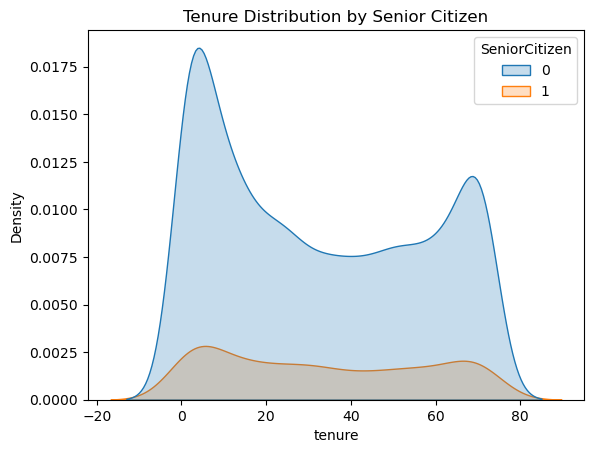

In [34]:
sns.kdeplot(data=df,x='tenure',hue='SeniorCitizen',fill=True)
plt.title('Tenure Distribution by Senior Citizen')
plt.show()


Senior citizens tend to churn earlier.
Useful demographic signal

## *Bivariate Analysis(Categorical):

In [35]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

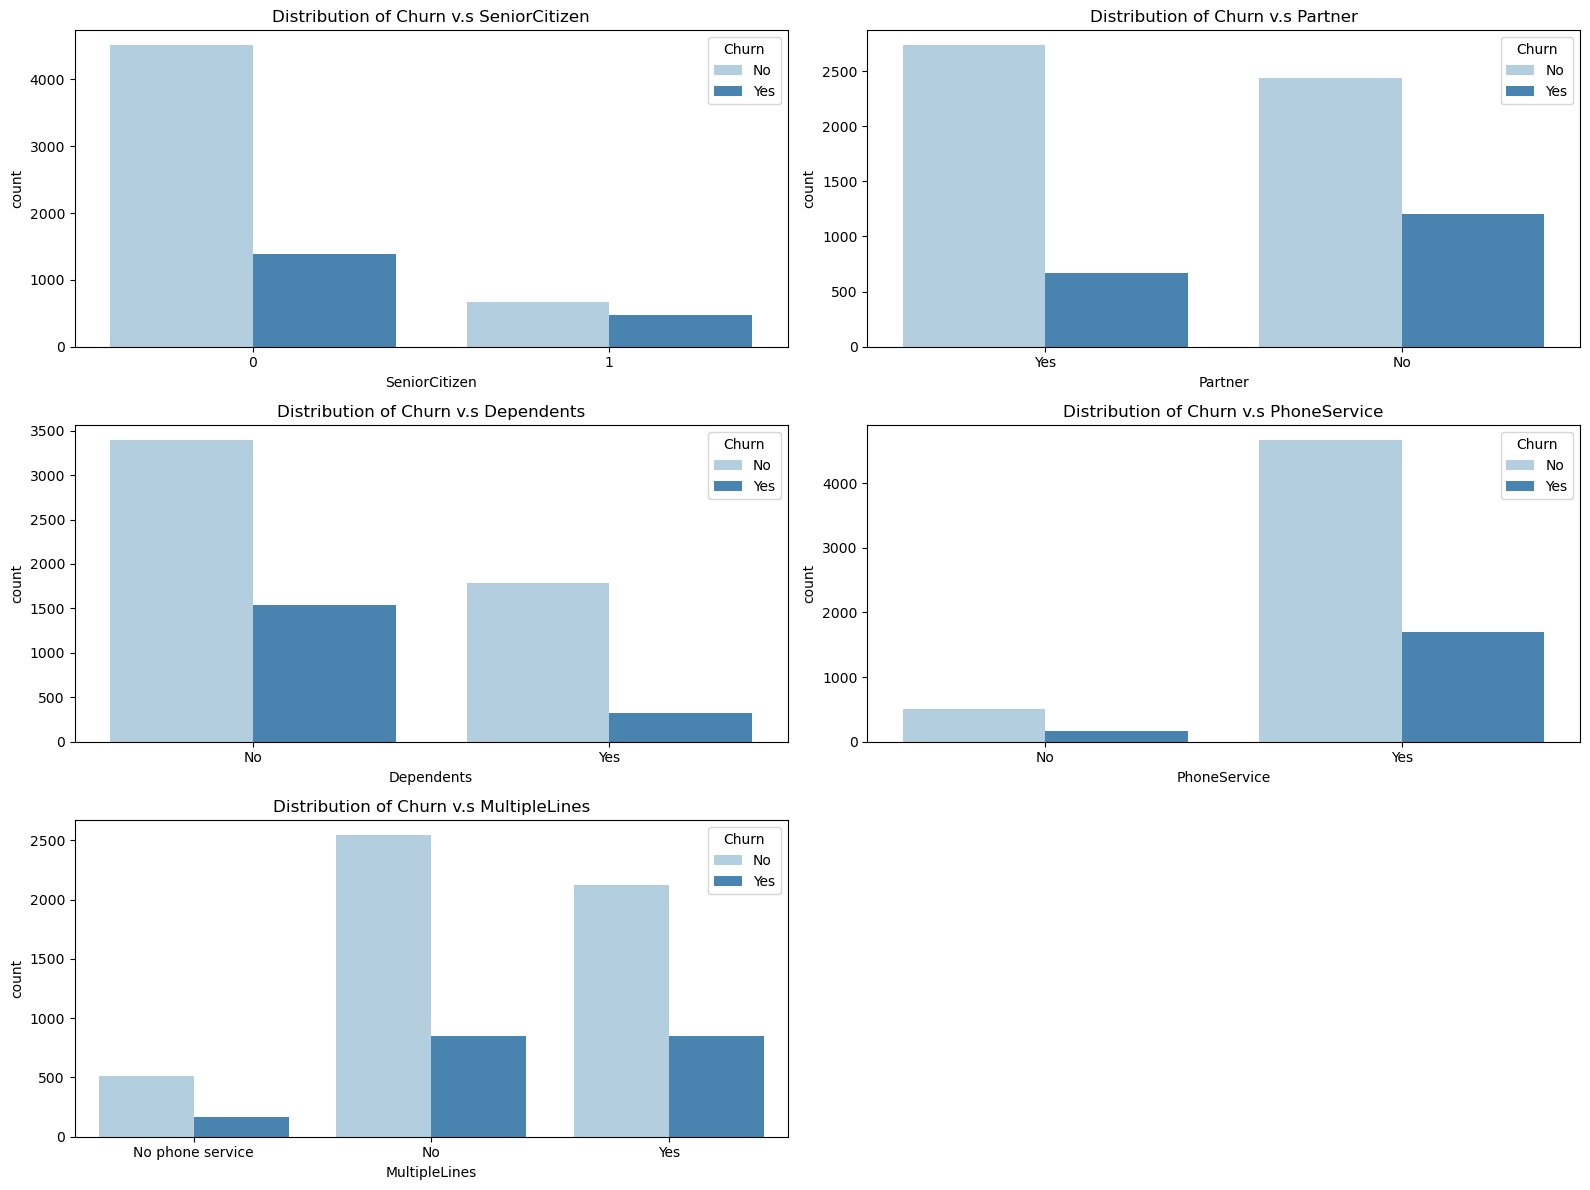

In [36]:
fig,axes=plt.subplots(3,2,figsize=(16,12))
axes=axes.flatten()
plt.subplots_adjust(hspace=0.9)
cols=['SeniorCitizen','Partner','Dependents','PhoneService','MultipleLines']
for i,col in enumerate(cols):
    sns.countplot( x=col,hue='Churn',palette='Blues',data=df,ax=axes[i])
    axes[i].set_title(f"Distribution of Churn v.s {col}")
fig.delaxes(axes[len(cols)])
plt.tight_layout()
plt.show()

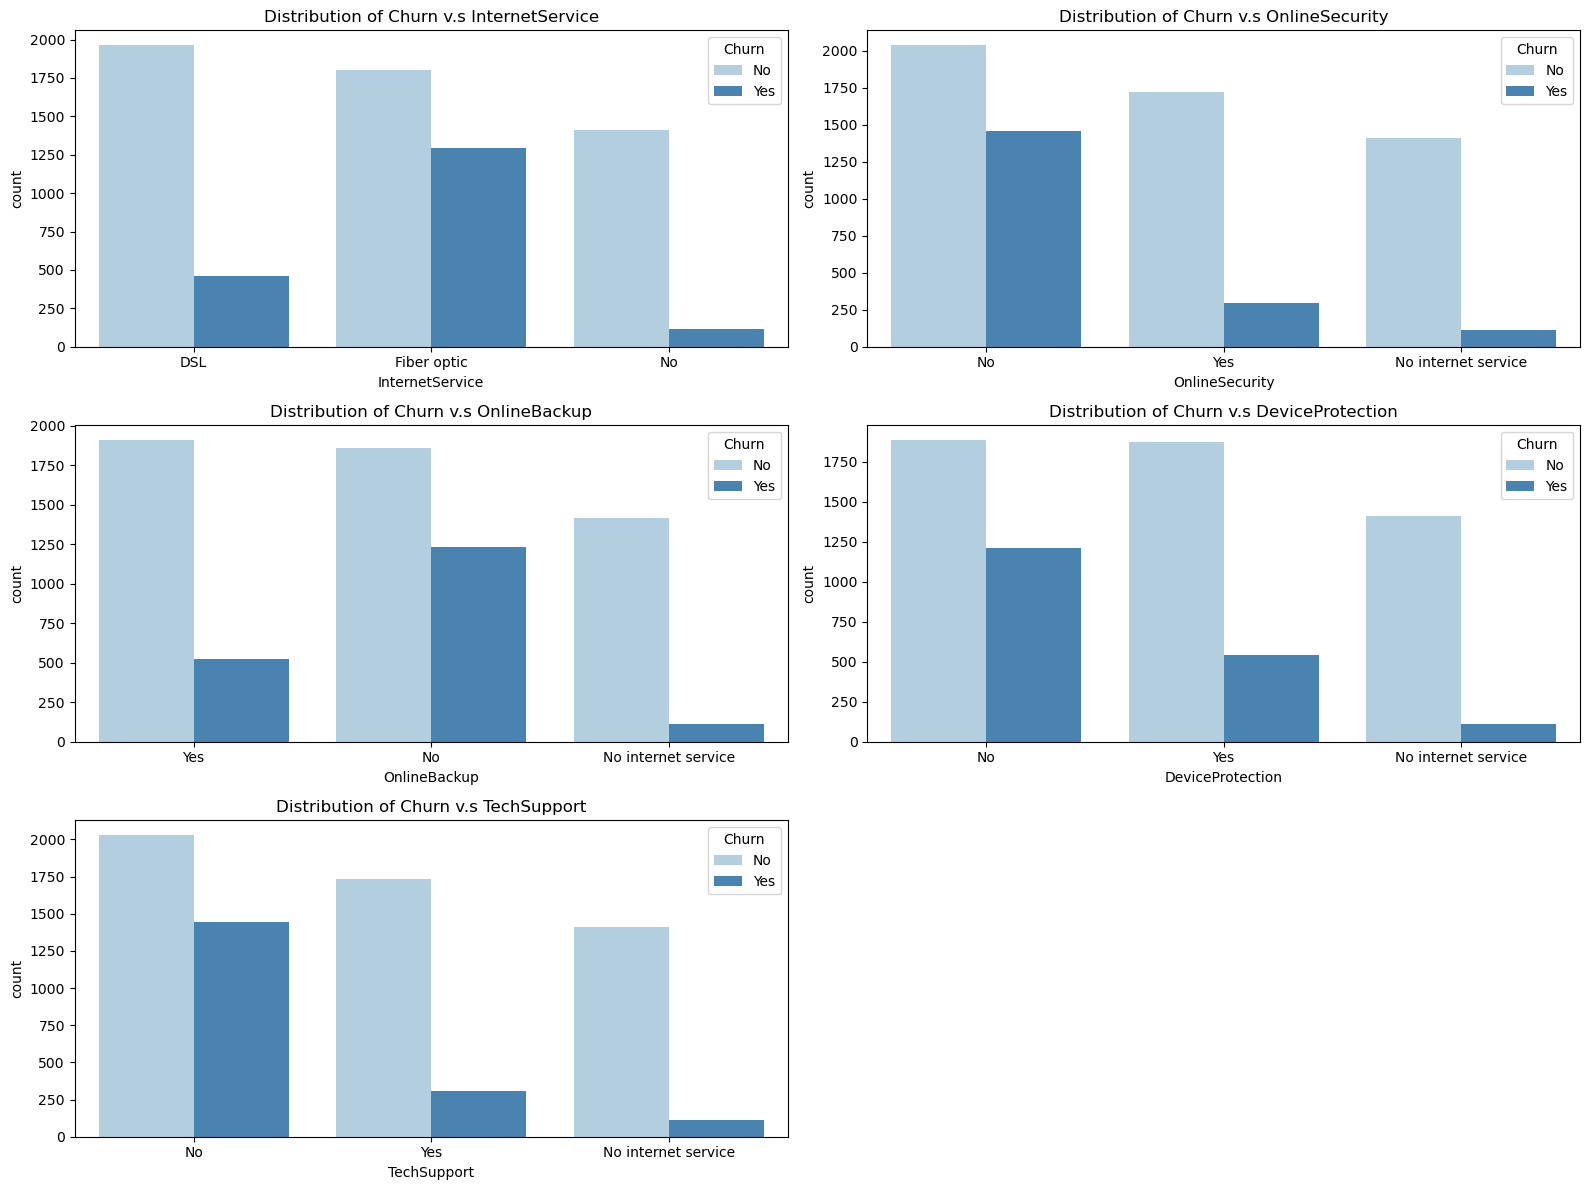

In [37]:
fig,axes=plt.subplots(3,2,figsize=(16,12))
axes=axes.flatten()
plt.subplots_adjust(hspace=0.9)
cols=['InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport']
for i,col in enumerate(cols):
    sns.countplot( x=col,hue='Churn',palette='Blues',data=df,ax=axes[i])
    axes[i].set_title(f"Distribution of Churn v.s {col}")
fig.delaxes(axes[len(cols)])
plt.tight_layout()
plt.show()

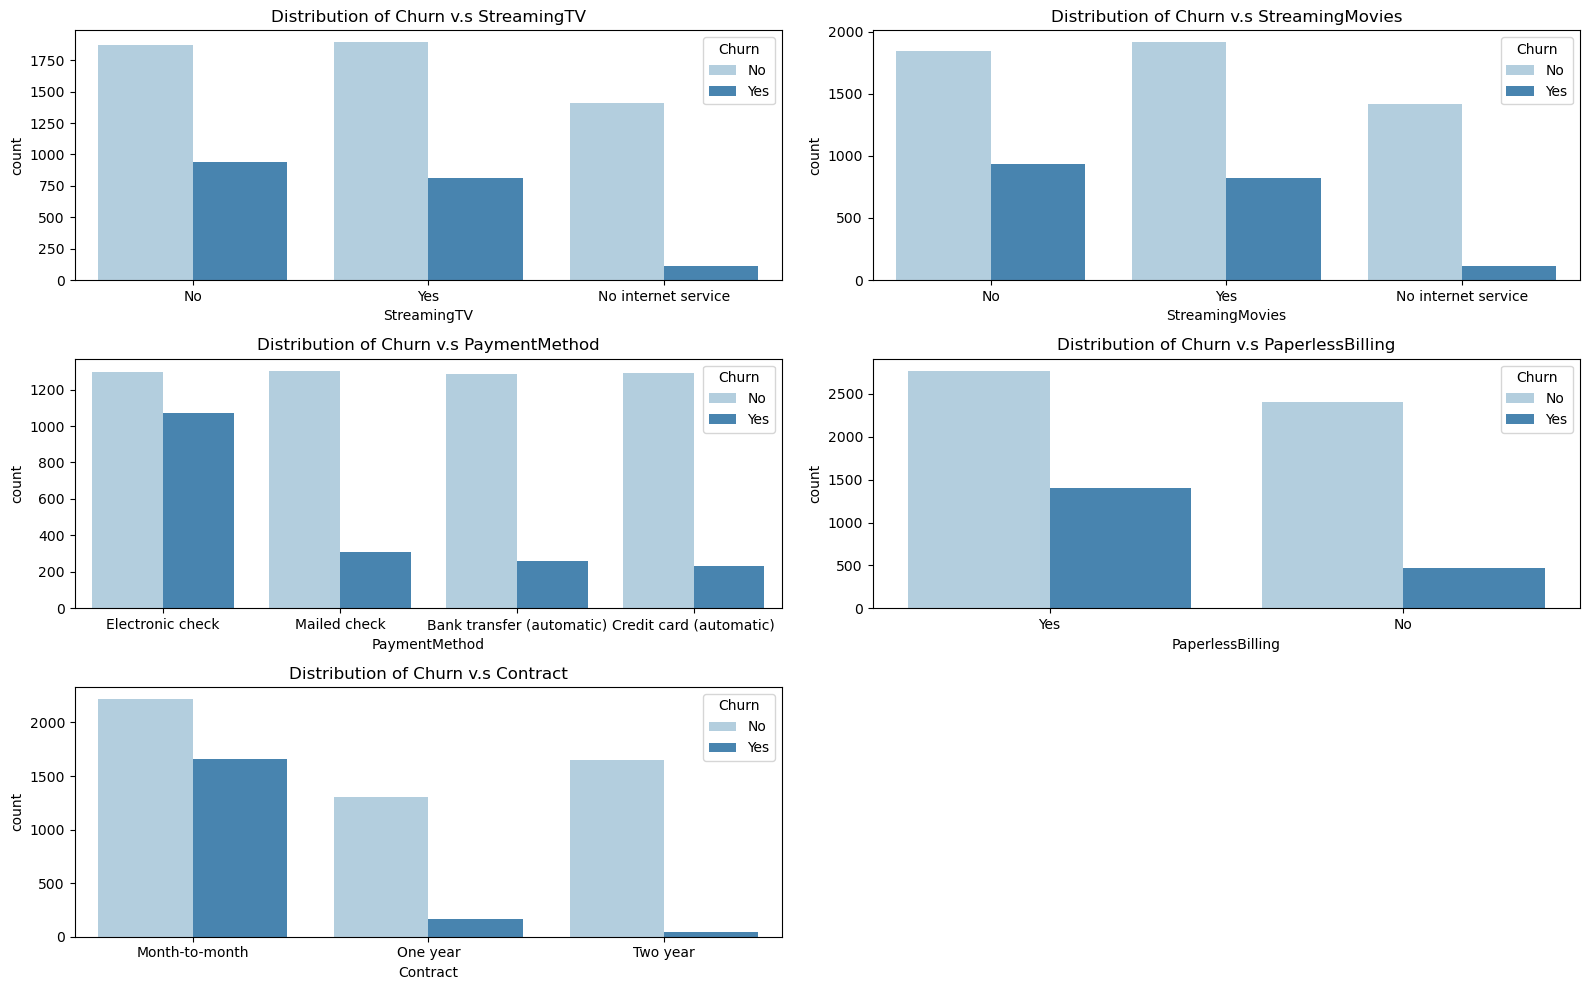

In [38]:
fig,axes=plt.subplots(3,2,figsize=(16,10))
axes=axes.flatten()
plt.subplots_adjust(hspace=0.9)
cols=['StreamingTV','StreamingMovies','PaymentMethod','PaperlessBilling','Contract']
for i,col in enumerate(cols):
    sns.countplot( x=col,hue='Churn',palette='Blues',data=df,ax=axes[i])
    axes[i].set_title(f"Distribution of Churn v.s {col}")
fig.delaxes(axes[len(cols)])
plt.tight_layout()
plt.show()

Month-to-month contracts:higher churn,
No TechSupport / OnlineSecurity:higher churn,
Senior citizens churn more.

# *Multivariate Analysis:

<Axes: xlabel='MonthlyCharges', ylabel='tenure'>

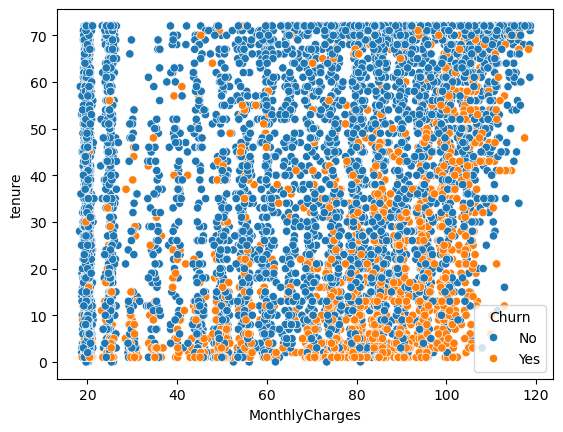

In [39]:
sns.scatterplot(x='MonthlyCharges', y='tenure', hue='Churn',  data=df)


High-charge customers with low tenure churn more.High-charge customers with low tenure churn more

<Axes: xlabel='Contract', ylabel='tenure'>

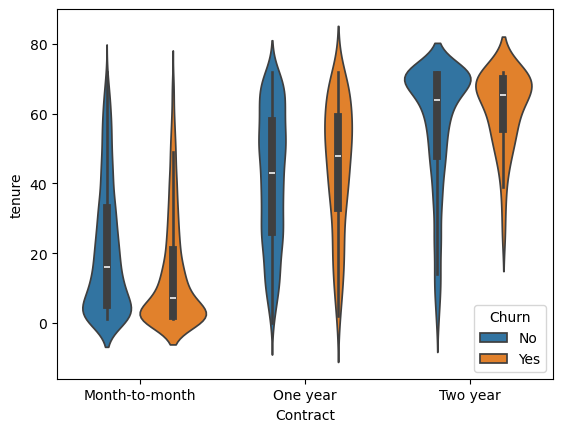

In [40]:
sns.violinplot(x='Contract', y='tenure', hue='Churn', data=df)

Month-to-month customers churn earlier.
Long-term contracts show retention stability

<Axes: xlabel='gender', ylabel='tenure'>

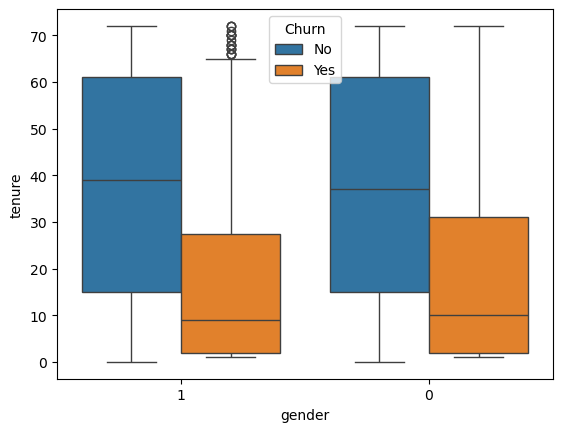

In [41]:
sns.boxplot(x='gender', y='tenure', hue='Churn', data=df)

Minimal difference between genders

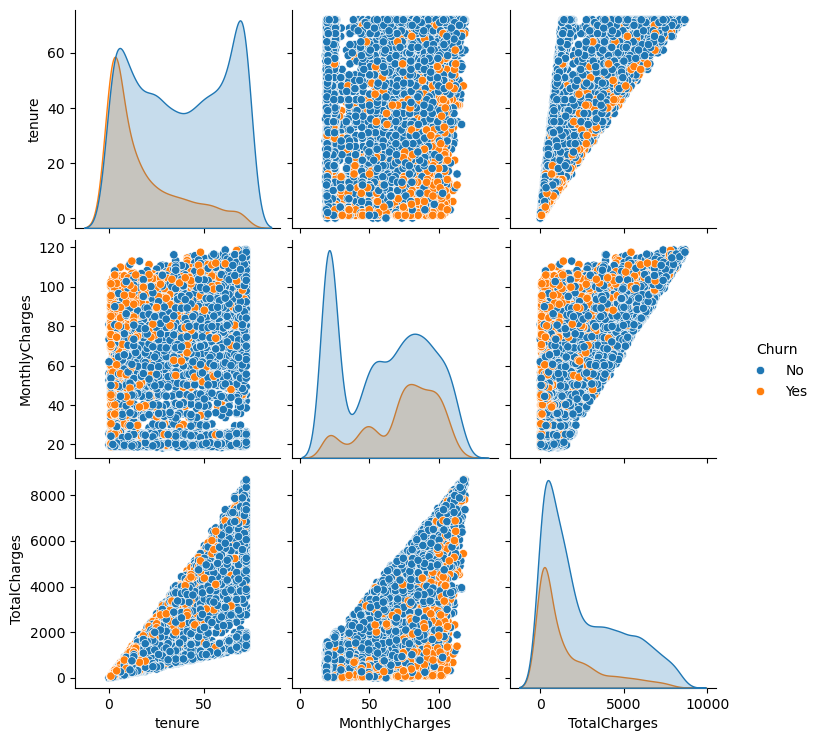

In [42]:
sns.pairplot(df, hue='Churn')
plt.show()

Clear separation based on tenure and charges.
Churn cluster visible at low tenure, high monthly charges

<Axes: >

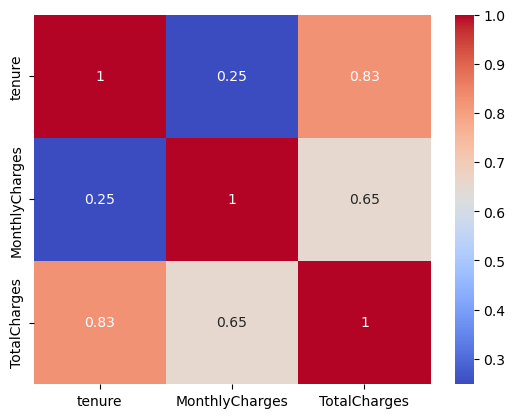

In [43]:
cols=['tenure','MonthlyCharges','TotalCharges']
sns.heatmap(df[cols].corr(),annot=True,cmap='coolwarm')


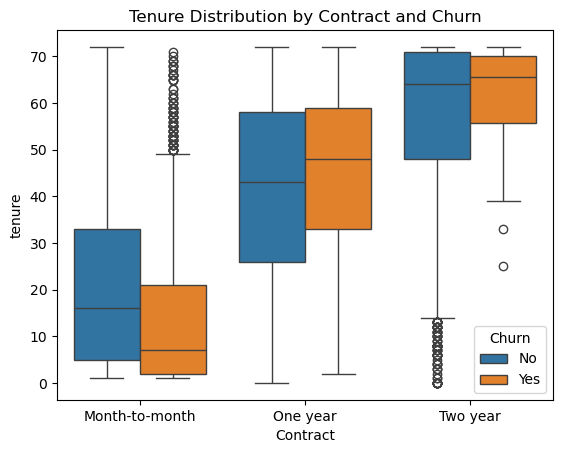

In [44]:
sns.boxplot(data=df,x='Contract',y='tenure',hue='Churn')
plt.title('Tenure Distribution by Contract and Churn')
plt.show()


Month-to-month customers churn early,
Long-term contracts show stability

Churn is strongly influenced by contract type, tenure, monthly charges, and service adoption. Customers with short tenure, month-to-month contracts, higher charges, and fewer support services are significantly more likely to churn.

# Feature Engineering

## -> Feature Creation:

In [45]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

## **Payment Methods:

In [46]:
df['PaymentMethod']

0                Electronic check
1                    Mailed check
2                    Mailed check
3       Bank transfer (automatic)
4                Electronic check
                  ...            
7038                 Mailed check
7039      Credit card (automatic)
7040             Electronic check
7041                 Mailed check
7042    Bank transfer (automatic)
Name: PaymentMethod, Length: 7043, dtype: object

In [47]:
df['tenure'].value_counts()

tenure
1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Name: count, Length: 73, dtype: int64

In [48]:
df.to_csv('cleaned_file.csv',index=False)